# Feynman-matroid zonotopes: worked examples via `pipeline.py`

Every example below feeds the **raw** physical constraint matrix (rows = edges, columns = ambient constraints) and a chosen column basis `B` (edge indices) into `pipeline.py`'s `compute_pipeline` / `plot_pipeline` / `run_pipeline`, which then handle basis reduction (paper eq. 1.21), the surviving sign vectors, the `Zonotope`, simplicial/non-simplicial classification for that basis, and plotting (see `pipeline.py`'s own module docstring for the full breakdown)


4 edges reduce to 4 independent hyperplane direction(s).
Search space: 2^4 = 16  ->  2^4 = 16 LP calls.
Pipeline summary
----------------------------------------------
  basis B         : (2, 3)  (det A_B = 1)
  ambient dim     : 2
  surviving cones : 8
    simplicial      : 8
    non-simplicial  : 0

  d = (1, 1, 1, 1)   q0 = (0, 0)
  --------------------------------------------------
     #     sigma           Q1        Q2  status
  --------------------------------------------------
     1                 -3.000     1.000  hull
     2                 -3.000    -1.000  hull
     3                  1.000    -3.000  hull
     4                 -1.000    -3.000  hull
     5                  1.000     3.000  hull
     6                 -1.000     3.000  hull
     7                  3.000     1.000  hull
     8                  3.000    -1.000  hull

  Hull: 8-gon   (8 of 8 sigma-points on hull)
  Predicted from directions: 8-gon  [matches]

  d = (1, 2, 3, 4)   q0 = (0, 0)
  -------------

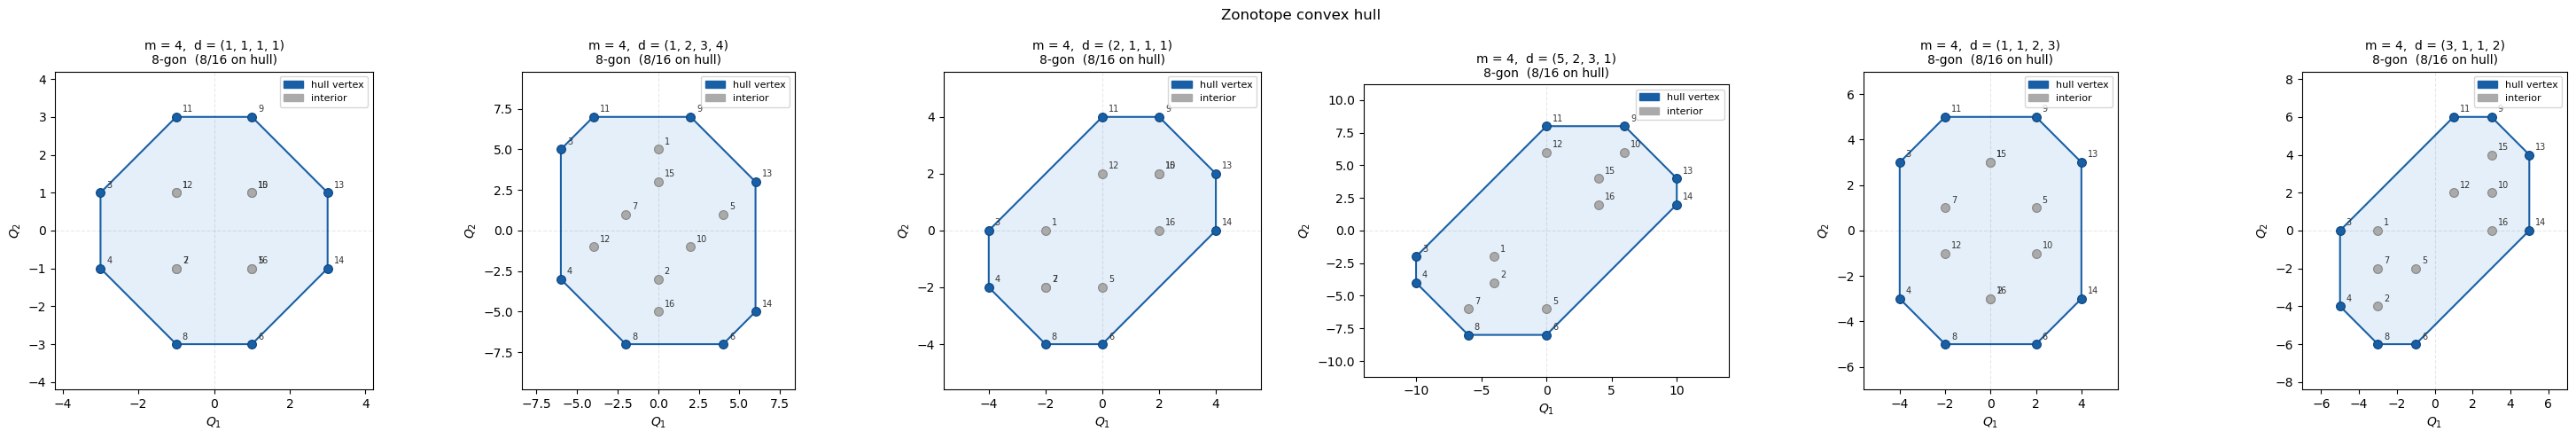

In [1]:
# ---------------------------------------------------------------------------
# Non-graphic matroid / octagon (paper eq. 1.11, sec. 1.2-1.3). Raw matrix,
# rows = edges e1..e4, columns = the two constraints; basis B = {e3, e4} is
# the paper's own choice. compute_pipeline() does the basis reduction and
# survivor search once -- the same 8 cones are then re-used to sweep the
# zonotope over several d-vectors, since only the vertex POSITIONS change
# with d, not the cone structure (paper sec. 1.3: "Concretely, let's say
# d_e = (1,1,1,1)...").
# ---------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pipeline import *
from zonotope_analysis import *

A_oct_raw = np.array([
    [1, 1],    # e1
    [1, -1],   # e2
    [-1, 0],   # e3
    [0, -1],   # e4
], dtype=float)

base = compute_pipeline(A_oct_raw, basis=[2, 3])  # prints the 8 surviving cones

demo_cases = [[1, 1, 1, 1],
              [1, 2, 3, 4],
              [2, 1, 1, 1],
              [5, 2, 3, 1],
              [1, 1, 2, 3],
              [3, 1, 1, 2]]
zs = [Zonotope(base.R_B, d=d) for d in demo_cases]
for z_i in zs:
    print_table(z_i, orientations=base.orientations)

fig = plot(zs)
plt.show()


  Primal hull: 8-gon,  dual: 8 vertices
    primal vertex          dual vertex       
  -------------------------------------------
  (  3.000,   1.000) ( -0.333333,  -0.000000)
  (  1.000,   3.000) ( -0.250000,  -0.250000)
  ( -1.000,   3.000) (  0.000000,  -0.333333)
  ( -3.000,   1.000) (  0.250000,  -0.250000)
  ( -3.000,  -1.000) (  0.333333,   0.000000)
  ( -1.000,  -3.000) (  0.250000,   0.250000)
  (  1.000,  -3.000) ( -0.000000,   0.333333)
  (  3.000,  -1.000) ( -0.250000,   0.250000)

  Area(P)  = 28.000000
  Area(P*) = 0.333333
  2! * Vol(P*) = 0.666667   (companion-paper normalisation |F|! Vol)

  Primal hull: 8-gon,  dual: 8 vertices
    primal vertex          dual vertex       
  -------------------------------------------
  ( -6.000,   5.000) ( -0.166667,  -0.000000)
  ( -6.000,  -3.000) ( -0.111111,  -0.111111)
  ( -2.000,  -7.000) (  0.000000,  -0.142857)
  (  4.000,  -7.000) (  0.090909,  -0.090909)
  (  6.000,  -5.000) (  0.166667,   0.000000)
  (  6.000,   3.000) (

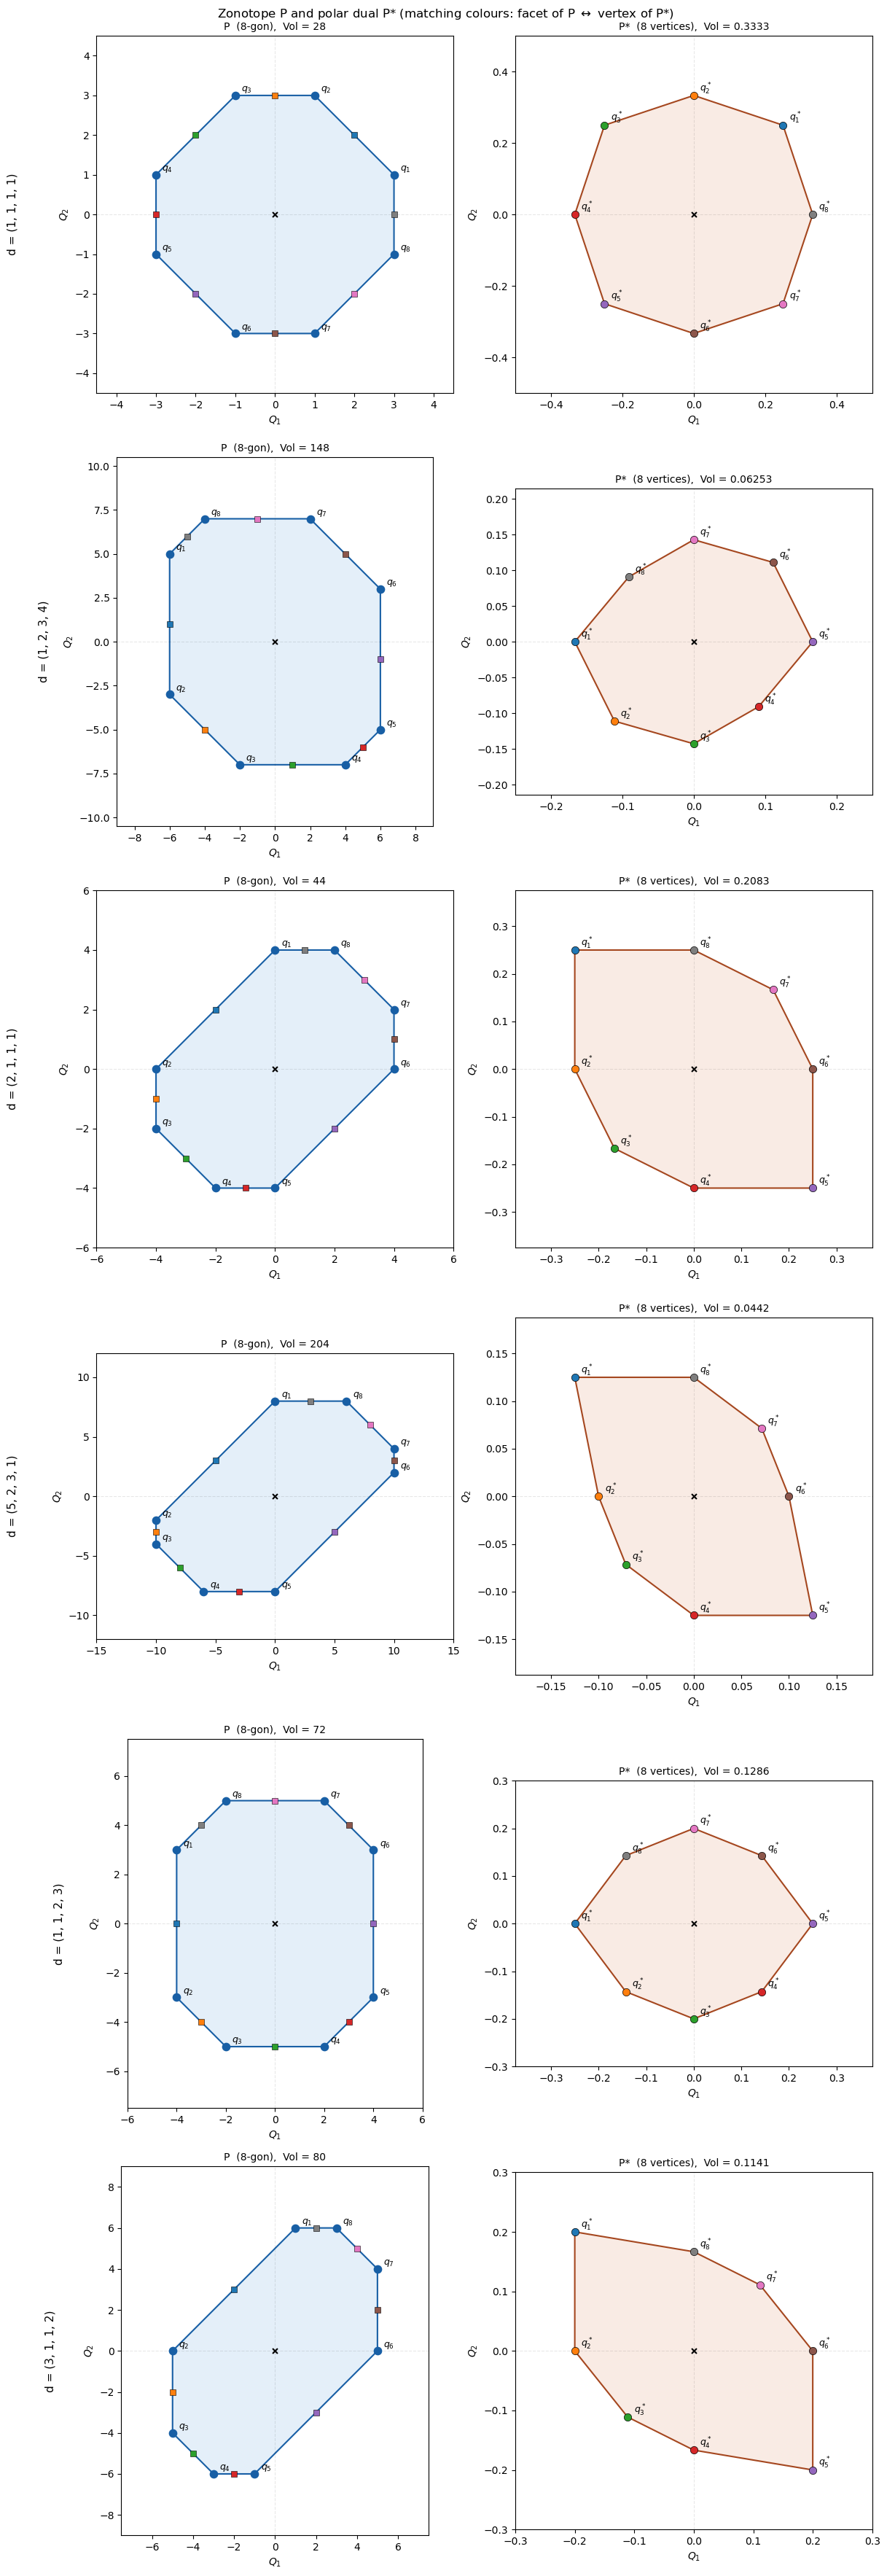

In [2]:
# ---------------------------------------------------------------------------
# Polar dual of the same octagon example, swept over the same d-vectors
# (reuses `base`/`demo_cases` from the previous cell).
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
from dual_analysis import print_dual_table, plot_primal_dual
from zonotope_analysis import Zonotope

zs = [Zonotope(base.R_B, d=d) for d in demo_cases]
for z_i in zs:
    print_dual_table(z_i, orientations=base.orientations, factorial_dim=2)

fig = plot_primal_dual(zs, orientations=base.orientations,
                        titles=[f"d = {tuple(d)}" for d in demo_cases])
plt.show()


5 edges reduce to 3 independent hyperplane direction(s).
Search space: 2^5 = 32  ->  2^3 = 8 LP calls.
Pipeline summary
----------------------------------------------
  basis B         : (2, 4)  (det A_B = 1)
  ambient dim     : 2
  surviving cones : 6
    simplicial      : 6
    non-simplicial  : 0

  d = (1, 1, 1, 1, 1)   q0 = (0, 0)
  --------------------------------------------------
     #      sigma            Q1        Q2  status
  --------------------------------------------------
     1                   -1.000    -4.000  hull
     2                   -3.000     0.000  hull
     3                   -3.000    -4.000  hull
     4                    3.000     4.000  hull
     5                    3.000     0.000  hull
     6                    1.000     4.000  hull

  Hull: 6-gon   (6 of 6 sigma-points on hull)
  Predicted from directions: 6-gon  [matches]



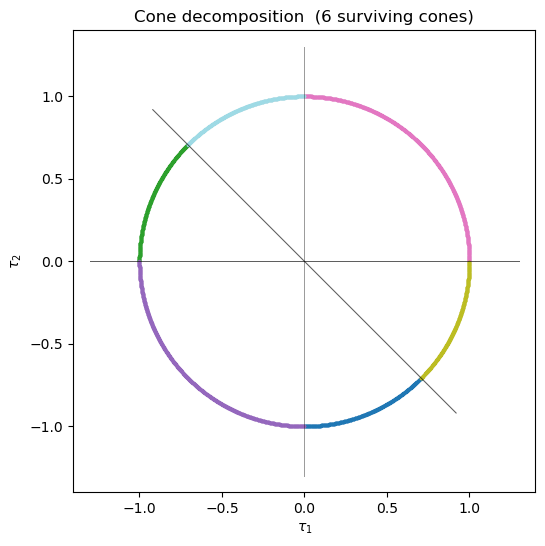

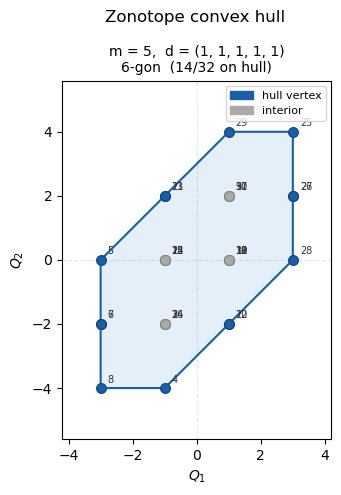

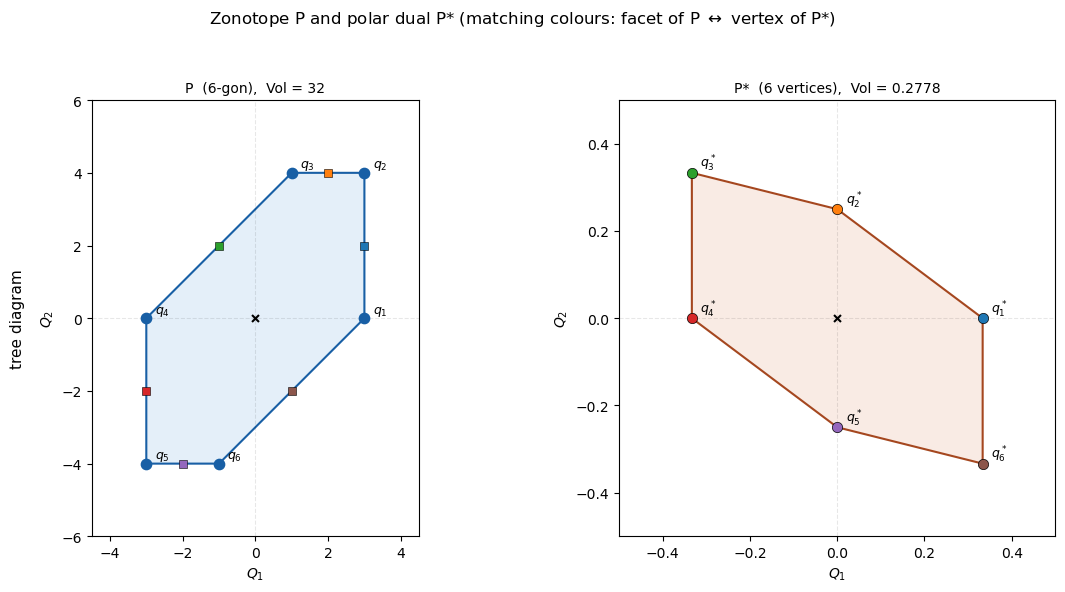

In [ ]:
# ---------------------------------------------------------------------------
# Tree diagram (paper sec. 3.1, dim = 2). Raw matrix, rows = edges e1..e5,
# columns = the two vertex constraints (eq. 3.2, transposed to this repo's
# rows-are-edges convention). Basis B = {e3, e5} ; same as in the paper
# ---------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pipeline import run_pipeline

A_tree_raw = np.array([
    [-1, 0],   # e1
    [-1, 0],   # e2
    [ 1, -1],  # e3
    [ 0,  1],  # e4
    [ 0,  1],  # e5
], dtype=float)

result, figs = run_pipeline(A_tree_raw, basis=[2, 4], titles=['tree diagram'])
# Expect: 6 surviving cones (hexagon), all simplicial; paper sec. 3.1.
plt.show()


5 edges reduce to 5 independent hyperplane direction(s).
Search space: 2^5 = 32  ->  2^5 = 32 LP calls.
Pipeline summary
----------------------------------------------
  basis B         : (1, 2, 4)  (det A_B = 1)
  ambient dim     : 3
  surviving cones : 18
    simplicial      : 16
    non-simplicial  : 2

  d = (1, 1, 1, 1, 1)   q0 = (0, 0, 0)
  --------------------------------------------------
     #      sigma            Q1        Q2        Q3  status
  --------------------------------------------------
     1                    0.000     3.000     0.000  hull
     2                    0.000     3.000    -2.000  hull
     3                    0.000     1.000     2.000  hull
     4                   -2.000     3.000     0.000  hull
     5                   -2.000     3.000    -2.000  hull
     6                   -2.000     1.000     2.000  hull
     7                   -2.000     1.000    -2.000  hull
     8                   -2.000    -1.000     2.000  hull
     9                 

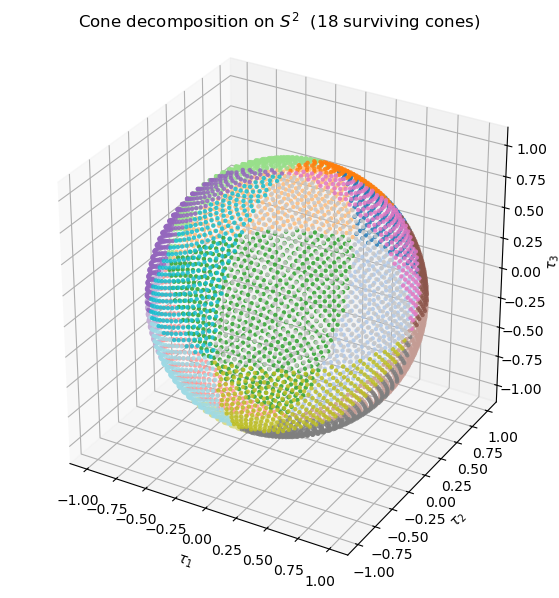

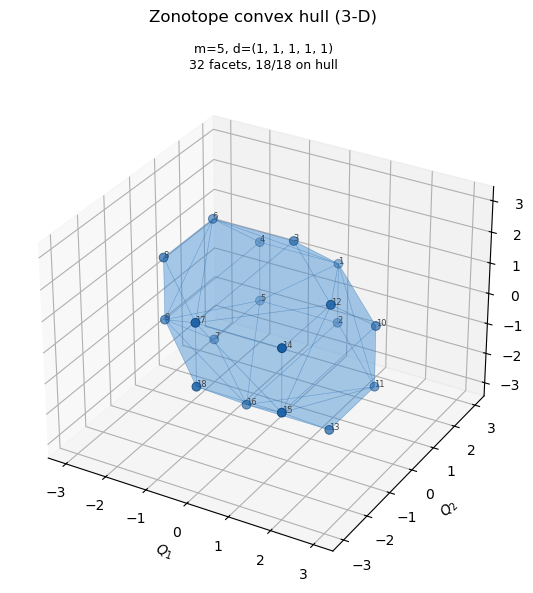

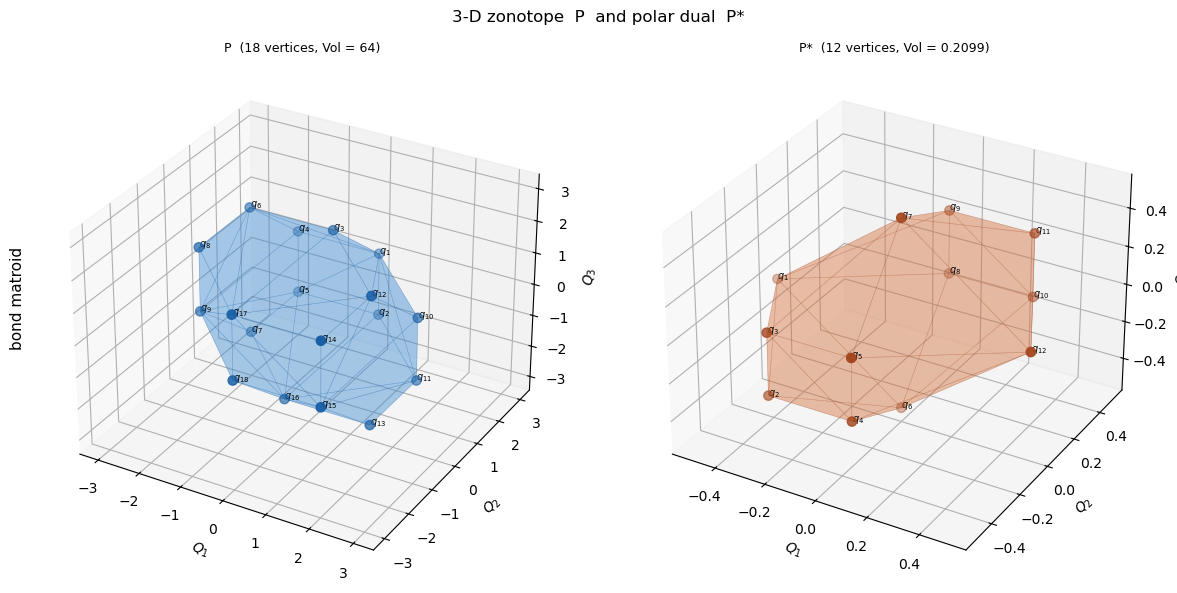

In [4]:
# ---------------------------------------------------------------------------
# Bond matroid (dim = 3), matplotlib rendering.
# ---------------------------------------------------------------------------
import numpy as np
from pipeline import run_pipeline

A_bond_raw = np.array([
    [ 1,  1,  0],   # e1
    [-1,  0,  0],   # e2
    [ 0,  1,  0],   # e3
    [ 0,  1,  1],   # e4
    [ 0,  0, -1],   # e5
], dtype=float)

result, figs = run_pipeline(A_bond_raw, basis=[1, 2, 4], interactive=False,
                             titles=['bond matroid'])
# Expect: 18 surviving cones (16 simplicial, 2 non-simplicial for this basis).


In [5]:
# ---------------------------------------------------------------------------
# Same bond matroid, Plotly (rotatable/zoomable) rendering.
# ---------------------------------------------------------------------------
import numpy as np
from pipeline import run_pipeline

A_bond_raw = np.array([
    [ 1,  1,  0],
    [-1,  0,  0],
    [ 0,  1,  0],
    [ 0,  1,  1],
    [ 0,  0, -1],
], dtype=float)

result, figs = run_pipeline(A_bond_raw, basis=[1, 2, 4], interactive=True,
                             titles=['bond matroid'])


5 edges reduce to 5 independent hyperplane direction(s).
Search space: 2^5 = 32  ->  2^5 = 32 LP calls.
Pipeline summary
----------------------------------------------
  basis B         : (1, 2, 4)  (det A_B = 1)
  ambient dim     : 3
  surviving cones : 18
    simplicial      : 16
    non-simplicial  : 2

  d = (1, 1, 1, 1, 1)   q0 = (0, 0, 0)
  --------------------------------------------------
     #      sigma            Q1        Q2        Q3  status
  --------------------------------------------------
     1                    0.000     3.000     0.000  hull
     2                    0.000     3.000    -2.000  hull
     3                    0.000     1.000     2.000  hull
     4                   -2.000     3.000     0.000  hull
     5                   -2.000     3.000    -2.000  hull
     6                   -2.000     1.000     2.000  hull
     7                   -2.000     1.000    -2.000  hull
     8                   -2.000    -1.000     2.000  hull
     9                 

In [ ]:
# ---------------------------------------------------------------------------
# Two-loop box diagram (dim = 4). Only Plotly rendering exists for 4-D in
# this repo, so plot_pipeline() picks interactive_4d_plots automatically.
# ---------------------------------------------------------------------------
import numpy as np
from pipeline import run_pipeline

A_box2_raw = np.array([
    [1, 0, 0, 0],
    [0, -1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, -1],
    [-1, 1, 0, 0],
    [0, 1, 1, 0],
    [0, 1, 1, 0],
    [0, 0, 1, 1],
    [-1, 0, 0, 1],
], dtype=float)

result, figs = run_pipeline(A_box2_raw, basis=[0, 1, 2, 3], titles=['two-loop box'])
# Expect: 78 surviving cones, 58 simplicial / 20 non-simplicial for this basis
# (the earlier version of this cell fed the same matrix into
# find_surviving_sign_vectors/Zonotope directly *and separately* into
# scan_matrix(basis=[0,1,2,3]) -- those two calls were silently using
# different generator matrices, since A_box2 restricted to rows [0,1,2,3] is
# diag(1,-1,1,-1), not the identity. run_pipeline performs that reduction
# once, consistently, from the raw matrix and basis alone.)


9 edges reduce to 8 independent hyperplane direction(s).
Search space: 2^9 = 512  ->  2^8 = 256 LP calls.
Pipeline summary
----------------------------------------------
  basis B         : (0, 1, 2, 3)  (det A_B = 1)
  ambient dim     : 4
  surviving cones : 78
    simplicial      : 58
    non-simplicial  : 20

  d = (1, 1, 1, 1, 1, 1, 1, 1, 1)   q0 = (0, 0, 0, 0)
  ---------------------------------------------------
     #          sigma                Q1        Q2        Q3        Q4  status
  ---------------------------------------------------
     1                            3.000     0.000     4.000     1.000  hull
     2                            3.000     0.000     2.000     3.000  hull
     3                            3.000     4.000     0.000     1.000  hull
     4                            3.000     4.000    -2.000     3.000  hull
     5                            1.000     0.000     4.000    -3.000  hull
     6                            3.000     0.000     4.000    -1.

In [17]:
# ---------------------------------------------------------------------------
# Two-loop bubble diagram (dim = 3), 
# with basis B = {e1, e5} 
# ---------------------------------------------------------------------------
import numpy as np
from pipeline import run_pipeline

A_2loop_raw = np.array([
    [-1, 0, 0],  # e1
    [ 1,-1, 0],  # e2
    [ 1,-1, 0],  # e3
    [ 0, 1,-1],  # e4
    [ 0, 1,-1],  # e5
    [ 0, 0, 1]   # e8
], dtype=float)

result, figs = run_pipeline(A_2loop_raw, basis=[0, 1, 5], titles=['Two loop bubble graph'])


6 edges reduce to 4 independent hyperplane direction(s).
Search space: 2^6 = 64  ->  2^4 = 16 LP calls.
Pipeline summary
----------------------------------------------
  basis B         : (0, 1, 5)  (det A_B = 1)
  ambient dim     : 3
  surviving cones : 14
    simplicial      : 8
    non-simplicial  : 6

  d = (1, 1, 1, 1, 1, 1)   q0 = (0, 0, 0)
  --------------------------------------------------
     #       sigma             Q1        Q2        Q3  status
  --------------------------------------------------
     1                     -1.000     0.000    -3.000  hull
     2                      3.000     4.000     3.000  hull
     3                      3.000     4.000     1.000  hull
     4                     -1.000    -4.000    -1.000  hull
     5                     -1.000    -4.000    -3.000  hull
     6                      3.000     0.000     3.000  hull
     7                      3.000     0.000     1.000  hull
     8                     -3.000     0.000    -1.000  hull
   

## Dimensions outside `{2, 3, 4}`

No spatial plotting exists anywhere in this repo for those, so `plot_pipeline()` falls back to the dimension-agnostic text report (`print_table` / `print_dual_table`) instead of erroring. Two synthetic examples below, since the paper's worked examples never go below dim = 2 or above dim = 4.


In [8]:
import numpy as np
from pipeline import compute_pipeline, plot_pipeline

# dim = 1: a single constraint, three edges.
A1_raw = np.array([[1.0], [-1.0], [2.0]])
r1 = compute_pipeline(A1_raw, basis=[0])
plot_pipeline(r1)

print()

# dim = 5: five unit generators plus one diagonal edge.
A5_raw = np.vstack([np.eye(5), np.ones((1, 5))])
r5 = compute_pipeline(A5_raw, basis=[0, 1, 2, 3, 4], verbose=False)
plot_pipeline(r5)


3 edges reduce to 3 independent hyperplane direction(s).
Search space: 2^3 = 8  ->  2^3 = 8 LP calls.
Pipeline summary
----------------------------------------------
  basis B         : (0,)  (det A_B = 1)
  ambient dim     : 1
  surviving cones : 2
    simplicial      : 2
    non-simplicial  : 0

No spatial plotting is available for dim == 1 (this repo only plots dim in (2, 3, 4)); showing the dimension-agnostic vertex/dual tables instead.

  d = (1, 1, 1)   q0 = (0)
  --------------------------------------------------
     #    sigma          Q1  status
  --------------------------------------------------
     1                4.000  hull
     2               -4.000  hull

  Hull: 2 endpoints   (2 of 2 sigma-points on hull)

  Primal hull: 2 endpoints,  dual: 2 vertices
  primal vertex dual vertex 
  ----------------------
  ( -4.000) ( -0.250000)
  (  4.000) (  0.250000)

  Length(P)  = 8.000000
  Length(P*) = 0.500000


No spatial plotting is available for dim == 5 (this repo only 

{}